In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Customer-Churn-Records.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.shape

(10000, 18)

In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'SatisfactionScore', 'CardType', 'PointEarned'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RowNumber          10000 non-null  int64  
 1   CustomerId         10000 non-null  int64  
 2   Surname            10000 non-null  object 
 3   CreditScore        10000 non-null  int64  
 4   Geography          10000 non-null  object 
 5   Gender             10000 non-null  object 
 6   Age                10000 non-null  int64  
 7   Tenure             10000 non-null  int64  
 8   Balance            10000 non-null  float64
 9   NumOfProducts      10000 non-null  int64  
 10  HasCrCard          10000 non-null  int64  
 11  IsActiveMember     10000 non-null  int64  
 12  EstimatedSalary    10000 non-null  float64
 13  Exited             10000 non-null  int64  
 14  Complain           10000 non-null  int64  
 15  SatisfactionScore  10000 non-null  int64  
 16  CardType           1000

In [7]:
df.isnull().sum()

RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Complain             0
SatisfactionScore    0
CardType             0
PointEarned          0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,PointEarned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [10]:
df.nunique()

RowNumber            10000
CustomerId           10000
Surname               2932
CreditScore            460
Geography                3
Gender                   2
Age                     70
Tenure                  11
Balance               6382
NumOfProducts            4
HasCrCard                2
IsActiveMember           2
EstimatedSalary       9999
Exited                   2
Complain                 2
SatisfactionScore        5
CardType                 4
PointEarned            785
dtype: int64

In [11]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


Surname:
['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']

--- Surname ---
Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
            ..
Izmailov     1
Bold         1
Bonham       1
Poninski     1
Burbidge     1
Name: count, Length: 2932, dtype: int64

Geography:
['France' 'Spain' 'Germany']

--- Geography ---
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
['Female' 'Male']

--- Gender ---
Gender
Male      5457
Female    4543
Name: count, dtype: int64

CardType:
['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']

--- CardType ---
CardType
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64


In [12]:
print(df['Complain'].value_counts())
print(df['Exited'].value_counts())
print(df['IsActiveMember'].value_counts())
print(df['HasCrCard'].value_counts())

Complain
0    7956
1    2044
Name: count, dtype: int64
Exited
0    7962
1    2038
Name: count, dtype: int64
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
HasCrCard
1    7055
0    2945
Name: count, dtype: int64


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [14]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64

In [15]:
df['CustomerId'].nunique()

10000

In [16]:
len(df)

10000

In [17]:
df.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Complain',
 'SatisfactionScore',
 'CardType',
 'PointEarned']

In [18]:
#How different are customers who exited from customers who stayed?
df.groupby("Exited")[[
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "SatisfactionScore",
    "PointEarned"
]].mean().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,SatisfactionScore,PointEarned
Exited,,,,,,,,
0,651.84,37.41,5.03,72742.75,1.54,99726.85,3.02,607.04
1,645.41,44.84,4.93,91109.48,1.48,101509.91,3.00,604.45


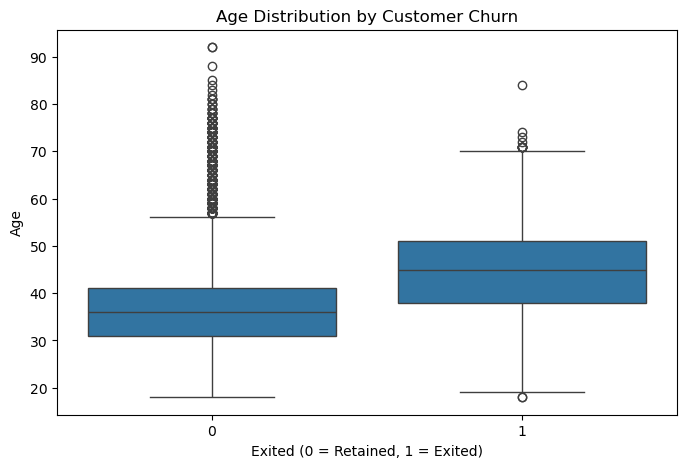

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Exited", y="Age")

plt.title("Age Distribution by Customer Churn")
plt.xlabel("Exited (0 = Retained, 1 = Exited)")
plt.ylabel("Age")

plt.show()

In [20]:
df.groupby("Exited")["Age"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.0,37.41,10.13,18.0,31.0,36.0,41.0,92.0
1,2038.0,44.84,9.76,18.0,38.0,45.0,51.0,84.0


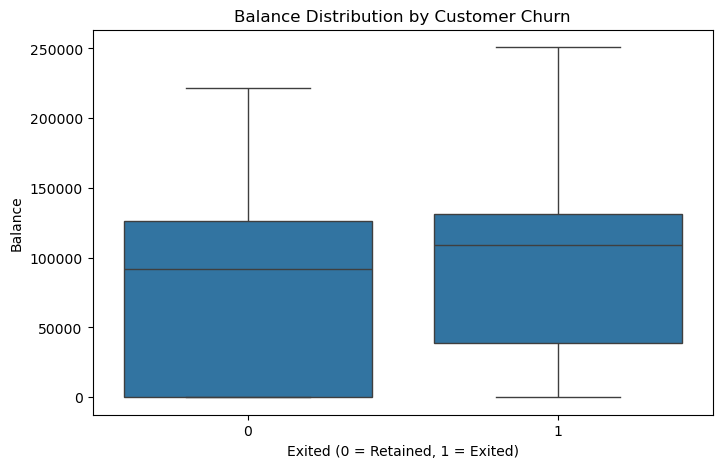

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Exited", y="Balance")

plt.title("Balance Distribution by Customer Churn")
plt.xlabel("Exited (0 = Retained, 1 = Exited)")
plt.ylabel("Balance")

plt.show()

In [22]:
df.groupby("Exited")["Balance"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.0,72742.75,62851.58,0.0,0.00,92063.06,126419.33,221532.80
1,2038.0,91109.48,58346.48,0.0,38591.22,109344.23,131423.64,250898.09


In [23]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

In [24]:
age_churn = (
    df.groupby("Age_Group", observed=True)["Exited"]
      .agg(["count", "mean"])
)

age_churn["Churn_Rate_%"] = age_churn["mean"] * 100

age_churn.drop(columns="mean").round(2)

,count,Churn_Rate_%
Age_Group,,
18-30,1968,7.52
31-40,4451,12.11
41-50,2320,33.97
51-60,797,56.21
60+,464,24.78


In [25]:
df["Balance_Group"] = pd.cut(
    df["Balance"],
    bins=[-1, 0, 50000, 100000, 150000, float("inf")],
    labels=[
        "Zero Balance",
        "1-50K",
        "50K-100K",
        "100K-150K",
        "150K+"
    ]
)

balance_churn = (
    df.groupby("Balance_Group", observed=True)["Exited"]
      .agg(["count", "mean"])
)

balance_churn["Churn_Rate_%"] = balance_churn["mean"] * 100

balance_churn.drop(columns="mean").round(2)

,count,Churn_Rate_%
Balance_Group,,
Zero Balance,3617,13.82
1-50K,75,34.67
50K-100K,1509,19.95
100K-150K,3830,25.77
150K+,969,23.12


In [26]:
complaint_churn = pd.crosstab(
    df["Complain"],
    df["Exited"],
    normalize="index"
) * 100

complaint_churn.round(2)

Exited,0,1
Complain,,
0,99.95,0.05
1,0.49,99.51


In [27]:
print(df["Complain"].value_counts())

Complain
0    7956
1    2044
Name: count, dtype: int64


In [28]:
print(
    pd.crosstab(
        df["Complain"],
        df["Exited"]
    )
)

Exited       0     1
Complain            
0         7952     4
1           10  2034


In [29]:
df.groupby("Exited")["SatisfactionScore"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
Exited,,,,,,
0,7962,3.02,3.0,1.41,1,5
1,2038,3.00,3.0,1.40,1,5


In [30]:
pd.crosstab(
    df["SatisfactionScore"],
    df["Exited"],
    normalize="index"
).mul(100).round(2)

Exited,0,1
SatisfactionScore,,
1,79.97,20.03
2,78.20,21.80
3,80.36,19.64
4,79.38,20.62
5,80.19,19.81


In [31]:
activity_churn = pd.crosstab(
    df["IsActiveMember"],
    df["Exited"],
    normalize="index"
) * 100

activity_churn.round(2)

Exited,0,1
IsActiveMember,,
0,73.13,26.87
1,85.73,14.27


In [32]:
pd.crosstab(
    df["IsActiveMember"],
    df["Exited"]
)

Exited,0,1
IsActiveMember,,
0,3546,1303
1,4416,735


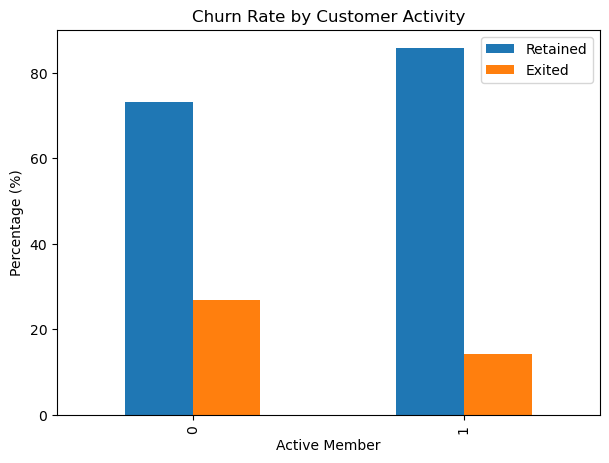

In [33]:
activity_churn.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Churn Rate by Customer Activity")
plt.xlabel("Active Member")
plt.ylabel("Percentage (%)")
plt.legend(["Retained", "Exited"])

plt.show()

In [34]:
product_churn = pd.crosstab(
    df["NumOfProducts"],
    df["Exited"],
    normalize="index"
) * 100

product_churn.round(2)

Exited,0,1
NumOfProducts,,
1,72.29,27.71
2,92.40,7.60
3,17.29,82.71
4,0.00,100.00


In [35]:
pd.crosstab(
    df["NumOfProducts"],
    df["Exited"]
)

Exited,0,1
NumOfProducts,,
1,3675,1409
2,4241,349
3,46,220
4,0,60


In [36]:
df.groupby("NumOfProducts")[
    [
        "Age",
        "CreditScore",
        "Balance",
        "EstimatedSalary",
        "SatisfactionScore",
        "PointEarned",
        "IsActiveMember"
    ]
].mean().round(2)

,Age,CreditScore,Balance,EstimatedSalary,SatisfactionScore,PointEarned,IsActiveMember
NumOfProducts,,,,,,,
1,39.67,649.12,98551.87,99487.26,3.03,609.58,0.50
2,37.75,652.19,51879.15,100452.01,2.99,603.70,0.53
3,43.20,648.11,75458.33,104318.13,3.13,603.89,0.42
4,45.68,653.58,93733.14,104763.72,2.80,574.23,0.48


In [37]:
df[df["NumOfProducts"].isin([3, 4])][[
    "Age",
    "CreditScore",
    "Balance",
    "EstimatedSalary",
    "SatisfactionScore",
    "PointEarned",
    "IsActiveMember",
    "Complain",
    "Exited"
]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,326.0,43.65,10.15,21.00,37.00,43.00,50.00,77.00
CreditScore,326.0,649.11,96.20,358.00,587.25,650.00,711.00,850.00
Balance,326.0,78821.79,62283.19,0.00,0.00,101628.67,128743.61,250898.09
EstimatedSalary,326.0,104400.14,55759.76,3440.47,64344.80,103874.67,151150.97,199357.24
SatisfactionScore,326.0,3.07,1.41,1.00,2.00,3.00,4.00,5.00
PointEarned,326.0,598.44,230.50,223.00,397.25,599.00,793.00,998.00
IsActiveMember,326.0,0.44,0.50,0.00,0.00,0.00,1.00,1.00
Complain,326.0,0.86,0.35,0.00,1.00,1.00,1.00,1.00
Exited,326.0,0.86,0.35,0.00,1.00,1.00,1.00,1.00


In [38]:
pd.crosstab(
    df["NumOfProducts"],
    df["IsActiveMember"],
    normalize="index"
).mul(100).round(2)

IsActiveMember,0,1
NumOfProducts,,
1,49.59,50.41
2,46.71,53.29
3,57.52,42.48
4,51.67,48.33


In [39]:
pd.crosstab(
    df["NumOfProducts"],
    df["IsActiveMember"]
)

IsActiveMember,0,1
NumOfProducts,,
1,2521,2563
2,2144,2446
3,153,113
4,31,29


In [40]:
product_activity_churn = pd.crosstab(
    [df["NumOfProducts"], df["IsActiveMember"]],
    df["Exited"],
    normalize="index"
) * 100

product_activity_churn.round(2)

Exited                            0       1
NumOfProducts IsActiveMember               
1             0               63.35   36.65
              1               81.08   18.92
2             0               90.07    9.93
              1               94.44    5.56
3             0               11.76   88.24
              1               24.78   75.22
4             0                0.00  100.00
              1                0.00  100.00

In [41]:
product_complaint_churn = pd.crosstab(
    [df["NumOfProducts"], df["Complain"]],
    df["Exited"],
    normalize="index"
) * 100

product_complaint_churn.round(2)

Exited                       0       1
NumOfProducts Complain                
1             0          99.92    0.08
              1           0.21   99.79
2             0          99.98    0.02
              1           1.97   98.03
3             0         100.00    0.00
              1           0.00  100.00
4             1           0.00  100.00

In [42]:
pd.crosstab(
    [df["NumOfProducts"], df["Complain"]],
    df["Exited"]
)

Exited                     0     1
NumOfProducts Complain            
1             0         3672     3
              1            3  1406
2             0         4234     1
              1            7   348
3             0           46     0
              1            0   220
4             1            0    60

In [43]:
df.groupby("Exited")["CreditScore"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.0,651.84,95.65,405.0,585.0,653.0,718.0,850.0
1,2038.0,645.41,100.34,350.0,578.0,646.0,716.0,850.0


In [44]:
df["CreditScore_Group"] = pd.cut(
    df["CreditScore"],
    bins=[0, 500, 600, 700, 800, 900],
    labels=[
        "Below 500",
        "500-600",
        "600-700",
        "700-800",
        "800+"
    ]
)

credit_churn = (
    df.groupby("CreditScore_Group", observed=True)["Exited"]
      .agg(["count", "mean"])
)

credit_churn["Churn_Rate_%"] = credit_churn["mean"] * 100

credit_churn.drop(columns="mean").round(2)

,count,Churn_Rate_%
CreditScore_Group,,
Below 500,643,23.64
500-600,2423,21.17
600-700,3818,19.72
700-800,2471,19.95
800+,645,19.69


In [45]:
geo_churn = pd.crosstab(
    df["Geography"],
    df["Exited"],
    normalize="index"
) * 100

geo_churn.round(2)

Exited,0,1
Geography,,
France,83.83,16.17
Germany,67.56,32.44
Spain,83.33,16.67


In [46]:
pd.crosstab(
    df["Geography"],
    df["Exited"]
)

Exited,0,1
Geography,,
France,4203,811
Germany,1695,814
Spain,2064,413


In [47]:
gender_churn = pd.crosstab(
    df["Gender"],
    df["Exited"],
    normalize="index"
) * 100

gender_churn.round(2)

Exited,0,1
Gender,,
Female,74.93,25.07
Male,83.53,16.47


In [48]:
pd.crosstab(
    df["Gender"],
    df["Exited"]
)

Exited,0,1
Gender,,
Female,3404,1139
Male,4558,899


In [49]:
card_churn = pd.crosstab(
    df["CardType"],
    df["Exited"],
    normalize="index"
) * 100

card_churn.round(2)

Exited,0,1
CardType,,
DIAMOND,78.22,21.78
GOLD,80.74,19.26
PLATINUM,79.64,20.36
SILVER,79.89,20.11


In [50]:
pd.crosstab(
    df["CardType"],
    df["Exited"]
)

Exited,0,1
CardType,,
DIAMOND,1961,546
GOLD,2020,482
PLATINUM,1987,508
SILVER,1994,502


In [51]:
df["Tenure_Group"] = pd.cut(
    df["Tenure"],
    bins=[-1, 2, 5, 8, 10],
    labels=[
        "0-2 years",
        "3-5 years",
        "6-8 years",
        "9-10 years"
    ]
)

tenure_churn = pd.crosstab(
    df["Tenure_Group"],
    df["Exited"],
    normalize="index"
) * 100

tenure_churn.round(2)

Exited,0,1
Tenure_Group,,
0-2 years,78.85,21.15
3-5 years,79.24,20.76
6-8 years,81.13,18.87
9-10 years,78.63,21.37


In [52]:
pd.crosstab(
    df["Tenure_Group"],
    df["Exited"]
)


Exited,0,1
Tenure_Group,,
0-2 years,1968,528
3-5 years,2385,625
6-8 years,2450,570
9-10 years,1159,315


In [53]:
df.groupby("Exited")["PointEarned"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.0,607.04,226.09,119.0,412.0,603.0,801.0,1000.0
1,2038.0,604.45,225.32,163.0,405.0,610.5,793.0,1000.0


In [54]:
df["Point_Earned_Group"] = pd.cut(
    df["PointEarned"],
    bins=[0, 400, 600, 800, 1000],
    labels=[
        "0-400",
        "401-600",
        "601-800",
        "801-1000"
    ]
)

point_churn = pd.crosstab(
    df["Point_Earned_Group"],
    df["Exited"],
    normalize="index"
) * 100

point_churn.round(2)

Exited,0,1
Point_Earned_Group,,
0-400,78.96,21.04
401-600,80.61,19.39
601-800,78.65,21.35
801-1000,80.21,19.79


In [55]:
pd.crosstab(
    df["Point_Earned_Group"],
    df["Exited"]
)

Exited,0,1
Point_Earned_Group,,
0-400,1861,496
401-600,2087,502
601-800,2008,545
801-1000,2006,495


In [56]:
df.groupby("Exited")["EstimatedSalary"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.0,99726.85,57399.96,90.07,50783.30,99620.36,148602.44,199992.48
1,2038.0,101509.91,57932.62,11.58,51924.02,102489.34,152443.86,199808.10


In [57]:
df["Salary_Group"] = pd.cut(
    df["EstimatedSalary"],
    bins=[0, 50000, 100000, 150000, 200000],
    labels=[
        "0-50K",
        "50K-100K",
        "100K-150K",
        "150K-200K"
    ]
)

salary_churn = pd.crosstab(
    df["Salary_Group"],
    df["Exited"],
    normalize="index"
) * 100

salary_churn.round(2)

Exited,0,1
Salary_Group,,
0-50K,80.07,19.93
50K-100K,80.13,19.87
100K-150K,79.77,20.23
150K-200K,78.49,21.51


In [58]:
pd.crosstab(
    df["Salary_Group"],
    df["Exited"]
)

Exited,0,1
Salary_Group,,
0-50K,1964,489
50K-100K,2033,504
100K-150K,2038,517
150K-200K,1927,528


In [59]:
df.shape

(10000, 24)

In [60]:
df.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Complain',
 'SatisfactionScore',
 'CardType',
 'PointEarned',
 'Age_Group',
 'Balance_Group',
 'CreditScore_Group',
 'Tenure_Group',
 'Point_Earned_Group',
 'Salary_Group']

In [61]:
original_columns = [
    'RowNumber',
    'CustomerId',
    'Surname',
    'CreditScore',
    'Geography',
    'Gender',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary',
    'Exited',
    'Complain',
    'SatisfactionScore',
    'CardType',
    'PointEarned'
]

df_clean = df[original_columns].copy()

In [62]:
df_clean.shape

(10000, 18)

In [63]:
#df_clean = df_clean.rename(columns={
   # 'Satisfaction Score': 'SatisfactionScore',
   # 'Card Type': 'CardType',
   # 'Point Earned': 'PointEarned'
#})

In [64]:
df_clean.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Complain',
 'SatisfactionScore',
 'CardType',
 'PointEarned']

In [65]:
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [66]:
df_clean.to_csv(
    "banking_customer_churn_clean.csv",
    index=False
)

In [67]:
import os

os.path.getsize("banking_customer_churn_clean.csv")

845030

In [68]:
df_clean.dtypes

RowNumber              int64
CustomerId             int64
Surname               object
CreditScore            int64
Geography             object
Gender                object
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Complain               int64
SatisfactionScore      int64
CardType              object
PointEarned            int64
dtype: object

In [149]:
!pip install pyodbc sqlalchemy

In [151]:
import pyodbc

pyodbc.drivers()

['SQL Server',
 'SQL Server Native Client RDA 11.0',
 'ODBC Driver 17 for SQL Server',
 'Microsoft Access Driver (*.mdb, *.accdb)',
 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)',
 'Microsoft Access Text Driver (*.txt, *.csv)',
 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']

In [157]:
from sqlalchemy import create_engine

engine = create_engine(
    "mssql+pyodbc://@localhost/BankingChurnAnalytics"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

In [159]:
with engine.connect() as connection:
    print("Connected successfully!")

Connected successfully!


In [161]:
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(text("SELECT DB_NAME()"))
    print(result.fetchone())

('BankingChurnAnalytics',)


In [163]:
df.to_sql(
    "banking_customers",
    con=engine,
    if_exists="replace",
    index=False
)

82

In [165]:
with engine.connect() as connection:
    result = connection.execute(
        text("""
            SELECT TABLE_NAME
            FROM INFORMATION_SCHEMA.TABLES
            WHERE TABLE_TYPE = 'BASE TABLE'
        """)
    )

    for row in result:
        print(row)

('banking_customers',)


In [167]:
df.to_sql(
    "banking_customers",
    con=engine,
    if_exists="replace",
    index=False
)

82

In [169]:
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) FROM banking_customers")
    )
    print("Rows in SQL Server:", result.fetchone()[0])

Rows in SQL Server: 10000


In [171]:
len(df)

10000